In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
#Load Dataset
df = pd.read_csv("European_Bank.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
#Statistical Summary
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
#Missing Values Check
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
#Duplicate Values Check
df.duplicated().sum()

np.int64(0)

In [7]:
#Drop Unnecessary Columns
df.drop(["CustomerId","Surname"], axis=1, inplace=True)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
#Create Age Groups
bins = [18,30,45,60,100]

labels = [
    "Young",
    "Adult",
    "Senior Adult",
    "Old"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult


In [9]:
#Create Credit Score Segments
def credit_segment(score):

    if score < 500:
        return "Low"

    elif score < 700:
        return "Medium"

    else:
        return "High"

df["CreditSegment"] = df["CreditScore"].apply(
    credit_segment
)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditSegment
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Medium
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Medium
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Medium
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High


In [10]:
#Create Balance Segments
def balance_segment(balance):

    if balance == 0:
        return "Zero Balance"

    elif balance < 100000:
        return "Medium Balance"

    else:
        return "High Value"

df["BalanceSegment"] = df["Balance"].apply(
    balance_segment
)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditSegment,BalanceSegment
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Medium,Zero Balance
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Medium Balance
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Medium,High Value
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Medium,Zero Balance
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,High Value


In [11]:
#Overall Churn Rate
churn_rate = round(
    df["Exited"].mean()*100,
    2
)

print(
    "Overall Churn Rate:",
    churn_rate,
    "%"
)

Overall Churn Rate: 20.37 %


In [12]:
#High Value Customer Churn
high_value = df[
    df["Balance"] > 100000
]

high_value_churn = round(
    high_value["Exited"].mean()*100,
    2
)

print(
    "High Value Customer Churn:",
    high_value_churn,
    "%"
)

High Value Customer Churn: 25.23 %


In [13]:
#Inactive Customer Churn
inactive = df[
    df["IsActiveMember"] == 0
]

inactive_churn = round(
    inactive["Exited"].mean()*100,
    2
)

print(
    "Inactive Customer Churn:",
    inactive_churn,
    "%"
)

Inactive Customer Churn: 26.85 %


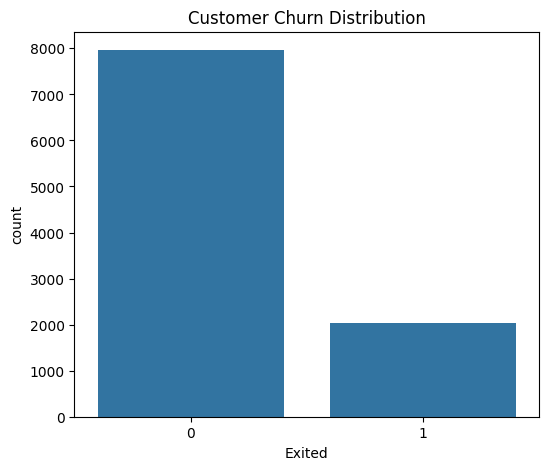

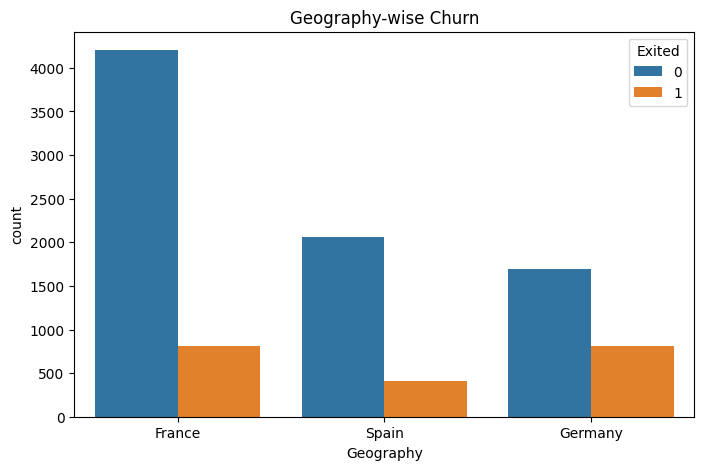

In [14]:
#Churn Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    x="Exited",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()
# Geography-wise Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

plt.title("Geography-wise Churn")

plt.show()

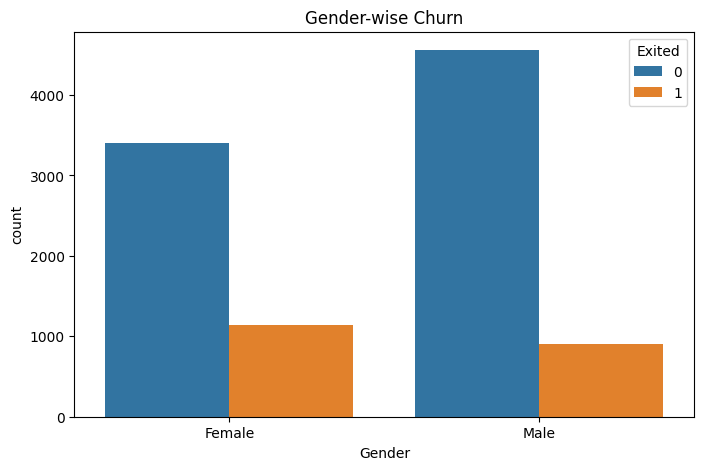

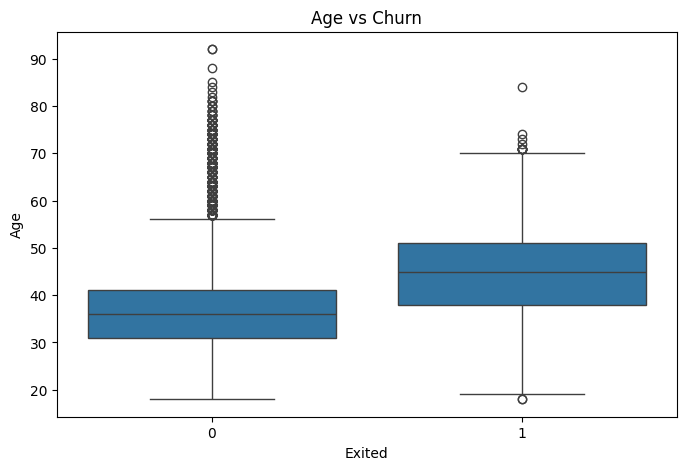

In [15]:
#Gender-wise Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Gender",
    hue="Exited",
    data=df
)

plt.title("Gender-wise Churn")

plt.show()
#Age vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

plt.title("Age vs Churn")

plt.show()


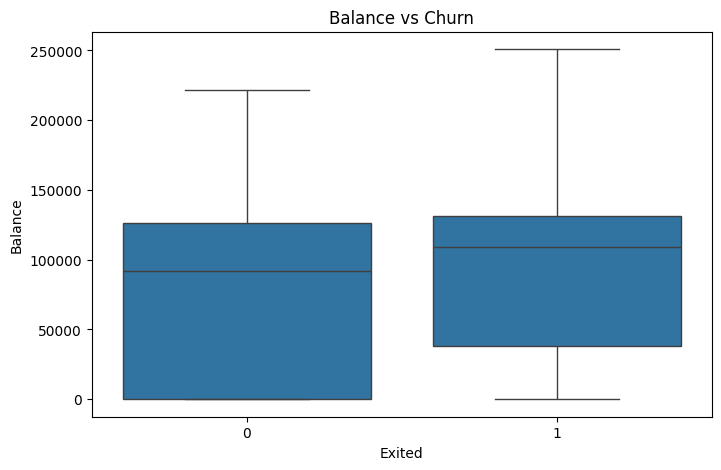

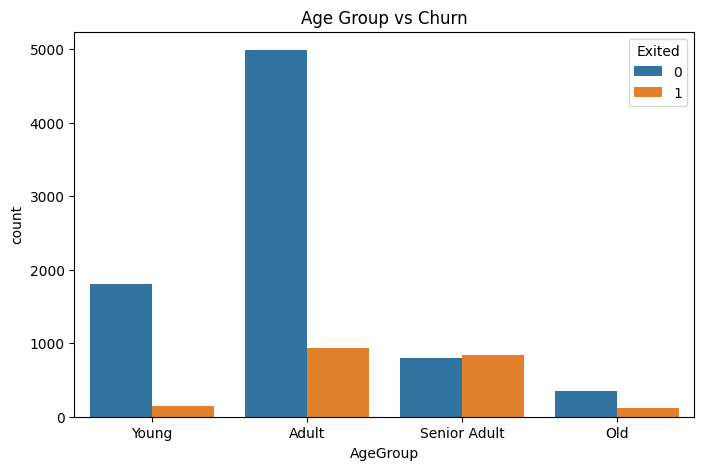

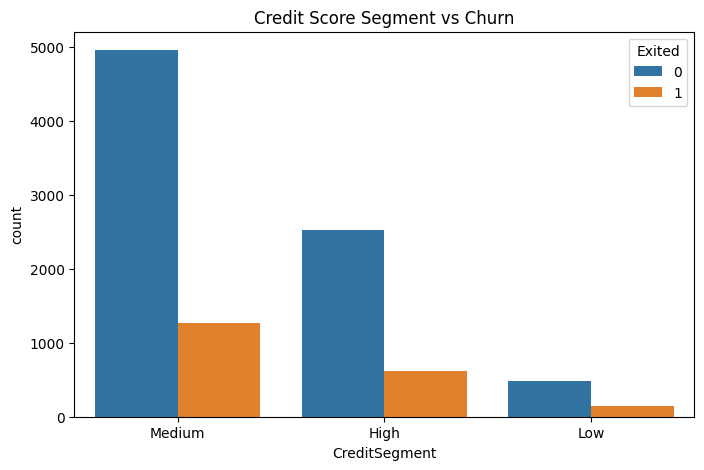

In [16]:
#Balance vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.title("Balance vs Churn")

plt.show()
#Churn by Age Group
plt.figure(figsize=(8,5))

sns.countplot(
    x="AgeGroup",
    hue="Exited",
    data=df
)

plt.title("Age Group vs Churn")

plt.show()
#Churn by Credit Segment
plt.figure(figsize=(8,5))

sns.countplot(
    x="CreditSegment",
    hue="Exited",
    data=df
)

plt.title("Credit Score Segment vs Churn")

plt.show()

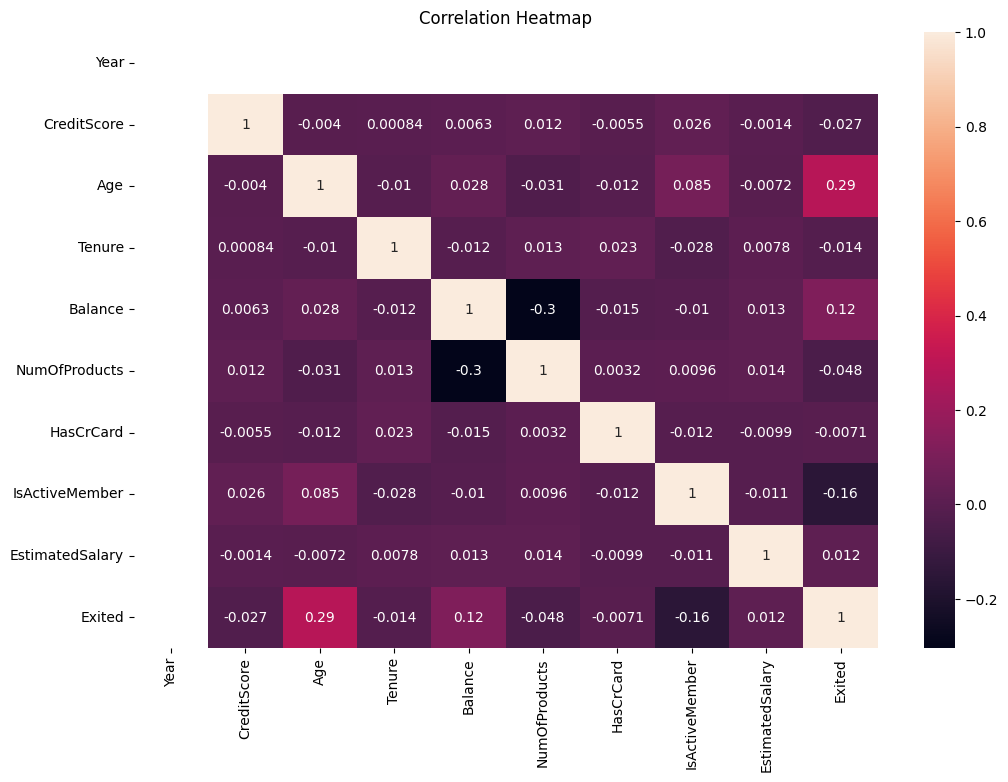

In [17]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()
#Machine Learning Preparation
df_ml = pd.get_dummies(
    df,
    drop_first=True
)

df_ml.head()
#Features and Target
X = df[['CreditScore',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'HasCrCard',
        'IsActiveMember',
        'EstimatedSalary']]

y = df['Exited']

In [18]:
#Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
#Prediction
y_pred = model.predict(
    X_test
)
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Model Accuracy:",
    round(accuracy*100,2),
    "%"
)
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 85.7 %
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1607
           1       0.74      0.42      0.54       393

    accuracy                           0.86      2000
   macro avg       0.80      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



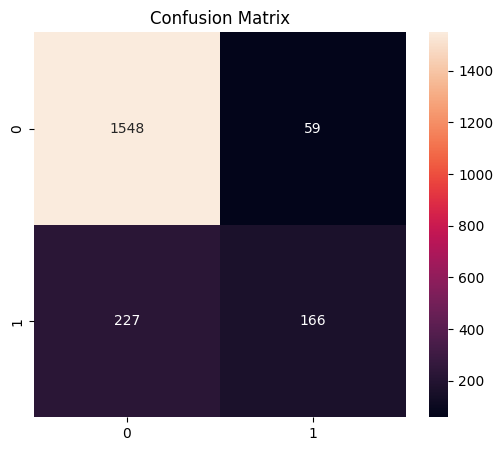

BUSINESS INSIGHTS
1. Germany has higher churn risk.
2. Inactive customers are more likely to leave.
3. Older customers show higher churn.
4. High balance customers create financial risk.
5. Customer engagement improves retention.
6. Machine Learning can help predict churn early.


In [20]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)
#Final Business Insights
print("BUSINESS INSIGHTS")

print("1. Germany has higher churn risk.")

print("2. Inactive customers are more likely to leave.")

print("3. Older customers show higher churn.")

print("4. High balance customers create financial risk.")

print("5. Customer engagement improves retention.")

print("6. Machine Learning can help predict churn early.")



In [21]:
!pip install joblib

In [22]:
import joblib

joblib.dump(model, "churn_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
import os

print(os.listdir())

['.gradio', '.ipynb_checkpoints', 'api.py', 'app.py', 'churn_analysis..ipynb', 'churn_model.pkl', 'Copy of Delinquency_prediction_dataset(2.csv).csv', 'credit data.csv', 'Cross Validation.ipynb', 'DBSCAN.ipynb', 'DecisionTree.ipynb', 'European_Bank.csv', 'faqs.txt', 'geldium_dataset(2.csv).csv', 'GridSearch and RandomSearchcv.ipynb', 'iris_joblib_model.joblib', 'iris_pickle_model.pkl', 'Joblib.ipynb', 'K-Means.ipynb', 'KNearest.ipynb', 'My Music', 'My Pictures', 'My Videos', 'Open source AI tools.ipynb', 'Pickle.ipynb', 'sales.csv', 'soil_dataset.csv', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', '__pycache__']


In [24]:
X.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [25]:
print(model.feature_names_in_)

AttributeError: 'RandomForestClassifier' object has no attribute 'feature_names_in_'